In [53]:
import numpy as np
import os
from skimage import io
from skimage.transform import resize
import matplotlib.pyplot as plt

In [54]:
np_res = np.random.gamma(shape=shape_parameter, scale=scale_parameter, size=size)


tf_op = tf.random_gamma(shape=size, alpha=shape_parameter, beta=1/scale_parameter)

NameError: name 'shape_parameter' is not defined

0.19980882
0.19930933440098295
0.4451706
0.44410893013857866


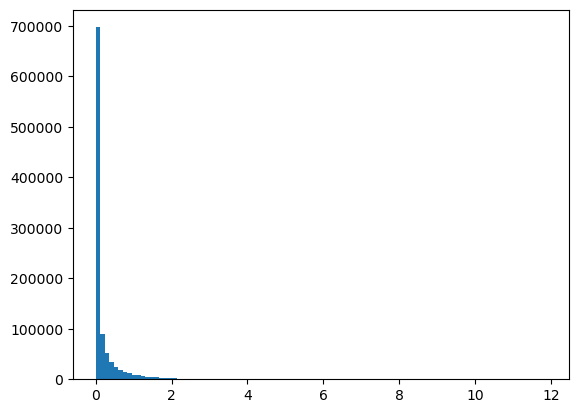

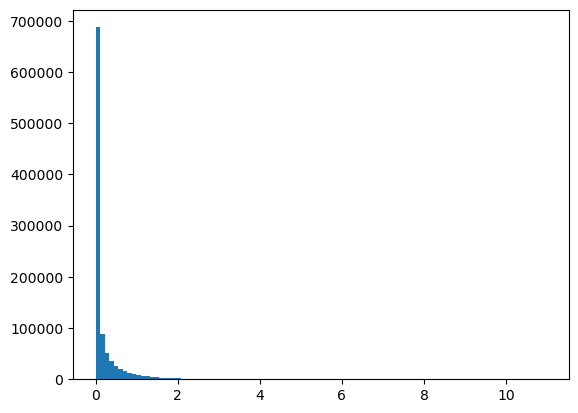

In [58]:
ssize=1000000
A = tf.random.gamma(shape=[ssize], alpha=0.2).numpy()
B=np.random.gamma(0.2,size=[ssize])
plt.hist(A,100)
plt.figure()
plt.hist(B,100)
print(np.mean(A))
print(np.mean(B))
print(np.std(A))
print(np.std(B))

In [62]:
import tensorflow as tf
def sample_beta_distribution(size, concentration_0=0.2, concentration_1=0.2, concentration_2=0.2):
    #gamma_1_sample = tf.random.gamma(shape=[size], alpha=concentration_0)
    gamma_1_sample = np.random.gamma(concentration_0,size=[size])
#    gamma_2_sample = tf.random.gamma(shape=[size], alpha=concentration_1)
    gamma_2_sample = np.random.gamma(concentration_1,size=[size])
#    gamma_3_sample = tf.random.gamma(shape=[size], alpha=concentration_2)
    gamma_3_sample = np.random.gamma(concentration_2,size=[size])
    sumGamma=gamma_1_sample + gamma_2_sample+gamma_3_sample
    return gamma_1_sample / sumGamma,gamma_2_sample/sumGamma,gamma_3_sample/sumGamma



batch_size = 7
alpha=0.2
#l = np.random.beta(alpha,alpha,batch_size)
l1,l2,l3 = sample_beta_distribution(batch_size,alpha,alpha)
print('l1.shape',l1.shape)
print('l2.shape',l2.shape)
print('l3.shape',l3.shape)
#coef = l.reshape(batch_size, 1, 1, 1)
#coef1 = tf.reshape(l1,(batch_size, 1, 1, 1))
#coef2 = tf.reshape(l2,(batch_size, 1, 1, 1))
#coef3 = tf.reshape(l3,(batch_size, 1, 1, 1))
coef1 = l1.reshape(batch_size, 1, 1, 1)
coef2 = l2.reshape(batch_size, 1, 1, 1)
coef3 = l3.reshape(batch_size, 1, 1, 1)

print('l.shape',l.shape)
print('coef1.shape',coef3.shape)
print('coef2.shape',coef3.shape)
print('coef3.shape',coef3.shape)
ima1=np.random.rand(batch_size,10,20,3)
dem1=np.random.rand(batch_size,10,20,1)
ima2=np.random.rand(batch_size,10,20,3)*2
dem2=np.random.rand(batch_size,10,20,1)*2
ima3=np.random.rand(batch_size,10,20,3)*3
dem3=np.random.rand(batch_size,10,20,1)*3
y1=np.random.rand(batch_size,10,20,1)
y2=np.random.rand(batch_size,10,20,1)
y3=np.random.rand(batch_size,10,20,1)
print('ima1',ima1.shape)
print('ima2',ima2.shape)
print('ima3',ima3.shape)
print('dem1',dem1.shape)
print('dem2',dem2.shape)
print('dem3',dem3.shape)
print('y1',y1.shape)
print('y2',y2.shape)
print('y3',y3.shape)
ima = ima1 * coef1 + ima2 * coef2 + ima3 * coef3
dem = dem1 * coef + dem2 * coef2 + dem3 * coef3
y = y1 * coef1 + y2 * coef2 + y3*coef3
print('sumc = ',coef1+coef2+coef3)
print('ima',ima.shape)
print('dem',dem.shape)
print('y',y.shape)



l1.shape (7,)
l2.shape (7,)
l3.shape (7,)
l.shape (7,)
coef1.shape (7, 1, 1, 1)
coef2.shape (7, 1, 1, 1)
coef3.shape (7, 1, 1, 1)
ima1 (7, 10, 20, 3)
ima2 (7, 10, 20, 3)
ima3 (7, 10, 20, 3)
dem1 (7, 10, 20, 1)
dem2 (7, 10, 20, 1)
dem3 (7, 10, 20, 1)
y1 (7, 10, 20, 1)
y2 (7, 10, 20, 1)
y3 (7, 10, 20, 1)
sumc =  [[[[1.]]]


 [[[1.]]]


 [[[1.]]]


 [[[1.]]]


 [[[1.]]]


 [[[1.]]]


 [[[1.]]]]
ima (7, 10, 20, 3)
dem (7, 10, 20, 1)
y (7, 10, 20, 1)


# Mixup Single Folder



In [2]:
# Useful function
def creation_folder(name):
    if not os.path.exists(name):
        os.makedirs(name)
        print('creation of ',name)


### Mixup single image

In [3]:
def mixup_single(input_folder_im,input_folder_dem,input_folder_mask,output_folder_im,output_folder_dem,output_folder_mask,nb_images=1000):
    """
    mixup between single folder
    """
    creation_folder(output_folder_dem)
    creation_folder(output_folder_mask)
    creation_folder(output_folder_im)
    name_i=os.listdir(input_folder_im)
    nb=len(name_i)
    for i in range(nb_images):
        ind=np.random.randint(0,nb,2)
        coef=np.random.rand(1)
#        print('im %d, names %s et %s, coef %.5f'%(i,name_i[ind[0]],name_i[ind[1]],coef))

        im0=io.imread('%s/%s'%(input_folder_im,name_i[ind[0]]))
        im1=io.imread('%s/%s'%(input_folder_im,name_i[ind[1]]))
        im_comb=coef*im0+(1-coef)*im1
#        name_save='%s/image_%.5d_c_%.3f.png'%(output_folder_im,i,coef)
        name_save='%s/image_%.5d.png'%(output_folder_im,i)
        io.imsave(name_save,np.clip(im_comb,0,255).astype(np.uint8))

        im0=io.imread('%s/%s'%(input_folder_dem,name_i[ind[0]]))
        im1=io.imread('%s/%s'%(input_folder_dem,name_i[ind[1]]))
        im_comb=coef*im0+(1-coef)*im1
#        name_save='%s/image_%.5d_c_%.3f.png'%(output_folder_dem,i,coef)
        name_save='%s/image_%.5d.png'%(output_folder_dem,i)
        io.imsave(name_save,np.clip(im_comb,0,255).astype(np.uint8))

        im0=io.imread('%s/%s'%(input_folder_mask,name_i[ind[0]]))
        im1=io.imread('%s/%s'%(input_folder_mask,name_i[ind[1]]))
        im_comb=coef*im0+(1-coef)*im1
#        name_save='%s/image_%.5d_c_%.3f.png'%(output_folder_mask,i,coef)
        name_save='%s/image_%.5d.png'%(output_folder_mask,i)
        io.imsave(name_save,np.clip(im_comb,0,255).astype(np.uint8))

In [20]:
c=np.random.dirichlet(np.ones(3),size=1)[0]
c[0]+c[1]+c[2]


1.0000000000000002

In [4]:
def mixup_single_folder_multi(input_folder_im,input_folder_dem,input_folder_mask,output_folder_im,output_folder_dem,output_folder_mask,nb_images=1000):
    """
    mixup between single folder
    """
    creation_folder(output_folder_dem)
    creation_folder(output_folder_mask)
    creation_folder(output_folder_im)
    name_i=os.listdir(input_folder_im)
    nb=len(name_i)
    for i in range(nb_images):
        ind=np.random.randint(0,nb,3)
        c=np.random.dirichlet(np.ones(3),size=1)[0]
#        print('im %d, names %s et %s, coef %.5f'%(i,name_i[ind[0]],name_i[ind[1]],coef))

        im0=io.imread('%s/%s'%(input_folder_im,name_i[ind[0]]))
        im1=io.imread('%s/%s'%(input_folder_im,name_i[ind[1]]))
        im2=io.imread('%s/%s'%(input_folder_im,name_i[ind[2]]))
        im_comb=c[0]*im0+c[1]*im1+c[2]*im2
#        name_save='%s/image_%.5d_c_%.3f.png'%(output_folder_im,i,coef)
        name_save='%s/image_%.5d.png'%(output_folder_im,i)
        io.imsave(name_save,np.clip(im_comb,0,255).astype(np.uint8))

        im0=io.imread('%s/%s'%(input_folder_dem,name_i[ind[0]]))
        im1=io.imread('%s/%s'%(input_folder_dem,name_i[ind[1]]))
        im2=io.imread('%s/%s'%(input_folder_dem,name_i[ind[2]]))
        im_comb=c[0]*im0+c[1]*im1+c[2]*im2
#        name_save='%s/image_%.5d_c_%.3f.png'%(output_folder_dem,i,coef)
        name_save='%s/image_%.5d.png'%(output_folder_dem,i)
        io.imsave(name_save,np.clip(im_comb,0,255).astype(np.uint8))

        im0=io.imread('%s/%s'%(input_folder_mask,name_i[ind[0]]))
        im1=io.imread('%s/%s'%(input_folder_mask,name_i[ind[1]]))
        im2=io.imread('%s/%s'%(input_folder_mask,name_i[ind[2]]))
        im_comb=c[0]*im0+c[1]*im1+c[2]*im2
#        name_save='%s/image_%.5d_c_%.3f.png'%(output_folder_mask,i,coef)
        name_save='%s/image_%.5d.png'%(output_folder_mask,i)
        io.imsave(name_save,np.clip(im_comb,0,255).astype(np.uint8))

### Test

In [ ]:
# Interpolation modes
modes = ('symmetric','linear_ramp','reflect','mean','resized')
for mod in modes:
    input_folder_im='./Bijie-landslide-dataset/landslide/images_256_%s/'%mod
    input_folder_dem='./Bijie-landslide-dataset/landslide/dem_256_%s/'%mod
    input_folder_mask='./Bijie-landslide-dataset/landslide/mask_256_%s/'%mod
    output_folder_im='./Bijie-landslide-dataset/landslide/mixup/images_%s/'%mod
    output_folder_dem='./Bijie-landslide-dataset/landslide/mixup/dem_%s/'%mod
    output_folder_mask='./Bijie-landslide-dataset/landslide/mixup/mask_%s/'%mod
    print('Create mixup for %s interpolation mode'%mod)
    mixup_single(input_folder_im,input_folder_dem,input_folder_mask,output_folder_im,output_folder_dem,output_folder_mask,nb_images=2500)


In [6]:
%%capture --no-display
input_folder_im='./datasets/constant/train/images/'
input_folder_dem='./datasets/constant/train/dem/'
input_folder_mask='./datasets/constant/train/mask/'
output_folder_im='./datasets/constant/train/mixup_multi/ima/'
output_folder_dem='./datasets/constant/train/mixup_multi/dem/'
output_folder_mask='./datasets/constant/train/mixup_multi/mask/'
mixup_single_folder_multi(input_folder_im,input_folder_dem,input_folder_mask,output_folder_im,output_folder_dem,output_folder_mask,nb_images=2500)


# Mixup Two Folders


In [5]:
def mixup_two(input_folder_im1,
              input_folder_dem1,
              input_folder_mask1,
              input_folder_im2,
              input_folder_dem2,
              input_folder_mask2,
              output_folder_im,
              output_folder_dem,
              output_folder_mask,
              nb_images=1000):
    """
    mixup between single folder
    """
    creation_folder(output_folder_dem)
    creation_folder(output_folder_mask)
    creation_folder(output_folder_im)
    name_1=os.listdir(input_folder_im1)
    name_2=os.listdir(input_folder_im2)
    nb1=len(name_1)
    nb2=len(name_2)
    for i in range(nb_images):
        ind1=np.random.randint(0,nb1)
        ind2=np.random.randint(0,nb2)
        coef=np.random.rand(1)
#        print('im %d, names %s et %s, coef %.5f'%(i,name_i[ind[0]],name_i[ind[1]],coef))

        im0=io.imread('%s/%s'%(input_folder_im1,name_1[ind1]))
        im1=io.imread('%s/%s'%(input_folder_im2,name_2[ind2]))
        im_comb=coef*im0+(1-coef)*im1
#        name_save='%s/image_%.5d_c_%.3f.png'%(output_folder_im,i,coef)
        name_save='%s/image_%.5d.png'%(output_folder_im,i)
        io.imsave(name_save,np.clip(im_comb,0,255).astype(np.uint8))

        im0=io.imread('%s/%s'%(input_folder_dem1,name_1[ind1]))
        im1=io.imread('%s/%s'%(input_folder_dem2,name_2[ind2]))
        im_comb=coef*im0+(1-coef)*im1
#        name_save='%s/image_%.5d_c_%.3f.png'%(output_folder_dem,i,coef)
        name_save='%s/image_%.5d.png'%(output_folder_dem,i)
        io.imsave(name_save,np.clip(im_comb,0,255).astype(np.uint8))

        im0=io.imread('%s/%s'%(input_folder_mask1,name_1[ind1]))
        im1=io.imread('%s/%s'%(input_folder_mask2,name_2[ind2]))
        im_comb=coef*im0+(1-coef)*im1
#        name_save='%s/image_%.5d_c_%.3f.png'%(output_folder_mask,i,coef)
        name_save='%s/image_%.5d.png'%(output_folder_mask,i)
        io.imsave(name_save,np.clip(im_comb,0,255).astype(np.uint8))

In [20]:
%%capture --no-display
# Interpolation modes
modes = ('symmetric','linear_ramp','reflect','mean','resized')
for mod in modes:
    input_folder_im1='./Bijie-landslide-dataset/landslide/images_256_%s/'%mod
    input_folder_dem1='./Bijie-landslide-dataset/landslide/dem_256_%s/'%mod
    input_folder_mask1='./Bijie-landslide-dataset/landslide/mask_256_%s/'%mod
    input_folder_im2='./Bijie-landslide-dataset/non-landslide/images_256_%s/'%mod
    input_folder_dem2='./Bijie-landslide-dataset/non-landslide/dem_256_%s/'%mod
    input_folder_mask2='./Bijie-landslide-dataset/non-landslide/mask_256_%s/'%mod
    output_folder_im='./Bijie-landslide-dataset/landslide/mixup_land_nonland/images_%s/'%mod
    output_folder_dem='./Bijie-landslide-dataset/landslide/mixup_land_nonland/dem_%s/'%mod
    output_folder_mask='./Bijie-landslide-dataset/landslide/mixup_land_nonland/mask_%s/'%mod
    print('Create mixup for %s interpolation mode'%mod)
    mixup_two(input_folder_im1,
              input_folder_dem1,
              input_folder_mask1,
              input_folder_im2,
              input_folder_dem2,
              input_folder_mask2,
              output_folder_im,
              output_folder_dem,
              output_folder_mask,nb_images=2500)
